# Taller 2 

## Integrantes:
- Felipe Villa Jaramillo
- Juan Pablo Cardona Bedoya


## Ejercicios

1. La distribución de temperatura de estado estable en una placa caliente está modeladas por la ecuación de LaPlace:

$$
0 = \frac{\partial^{2}T}{\partial x^{2}}
$$
Si se representa la placa por una serie de nodos, las diferencias finitas divididas se pueden sustituir por las segundas derivadas, lo que da como resultado un sistema de ecuaciones algebraicas lineales.

![gráfica](https://i.gyazo.com/3dcbac42ab97ef9c52f128a736237fb4.png)

- a) Utilice el método de Gauss-Seidel matrices para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- b) Utilice el método de Gauss-Seidel sumas para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- c) Utilice el método de Jacobi sumas para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- d ) Utilice el método de Jacobi matrices para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- e) Calcule el tiempo de cómputo de cada sistema y grafique los errores( es decir xgs con xgm y xjs con xjm ) y saque conclusiones

Como podemos utilizar laplace para aproximar de forma discreta $T_{i,j}=\frac{1}{4}(T_{i+1,j}+T_{i-1,j}+T_{i,j+1}+T_{i,j-1})$ entonces podemos saber que en un nodo la temperatura es el promedio de sus 4 vecinos.

- Entonces para $T_{11}$ los vecinos son:

    - Arriba: $T_{12}$
    - Derecha: $T_{21}$
    - Izquierda: 100
    - Abajo: 75

    Entonces la ecuación queda de esta forma:
    $$T_{11} = \frac{1}{4}(T_{12} + T_{21} + 175)$$
    - Despejando:
    $$4T_{11} - T_{12} - T_{21} = 175$$

- Entonces para $T_{12}$ los vecinos son:

    - Arriba: 25
    - Derecha: $T_{22}$
    - Izquierda: 100
    - Abajo: $T_{11}$

    - Entonces la ecuación queda de esta forma:
    $$T_{12} = \frac{1}{4}(T_{11} + T_{22} + 125)$$
    - Despejando:
    $$4T_{12} - T_{11} - T_{22}= 125$$

- Entonces para $T_{21}$ los vecinos son:

    - Arriba: $T_{22}$
    - Derecha: 0
    - Izquierda: $T_{11}$
    - Abajo: 75

    - Entonces la ecuación queda de esta forma:
    $$T_{21} = \frac{1}{4}(T_{11} + T_{22} + 75)$$
    - Despejando:
    $$4T_{21} - T_{11} - T_{22} = 75$$

- Entonces para $T_{22}$ los vecinos son:

    - Arriba: 25
    - Derecha: 0
    - Izquierda: $T_{12}$
    - Abajo: $T_{21}$

    - Entonces la ecuación queda de esta forma:
    $$T_{22} = \frac{1}{4}(T_{12} + T_{21} + 25)$$
    - Despejando:
    $$4T_{22} - T_{12} - T_{21}=25$$

Con lo anterior ya podemos empezar a resolver cada item

## Item (a)

In [22]:
import numpy as np
from sel import gauss_seidel_matrices

A = np.array([[4, -1, -1, 0],
              [-1, 4, 0, -1],
              [-1, 0, 4, -1],
              [0, -1, -1, 4]], dtype=float)

b = np.array([175, 125, 75, 25], dtype=float)
x0 = np.zeros_like(b)

sol_gauss_seidel_matrices = gauss_seidel_matrices(A, b, x0, 1e-6)
print("Gauss Seidel con matrices:", sol_gauss_seidel_matrices)

Radio espectral: 0.24999999999999997
Gauss Seidel con matrices: (array([68.7499999 , 56.24999995, 43.74999995, 31.24999997]), np.float64(3.14321368932724e-07), 0.0004830360412597656, 16)


## Item (b)

In [23]:
# TODO Método de Gauss Seidel con sumas

## Item(c)

In [24]:
from sel import jacobi_con_sumas

sol_jacobi_con_sumas = jacobi_con_sumas(A, b, x0, 1000, 1e-6)
print("Jacobi con sumas:", sol_jacobi_con_sumas)

Jacobi con sumas: (array([68.74999925, 56.24999925, 43.74999925, 31.24999925]), np.float64(7.450580596923828e-07), 0.0042989253997802734, 26)


## Item(d)

In [25]:
from sel import jacobi_con_matrices

sol_jacobi_con_matrices = jacobi_con_matrices(A, b, x0, 1e-6)
print("Jacobi con matrices:", sol_jacobi_con_matrices)

0.5
Jacobi con matrices: (array([68.74999925, 56.24999925, 43.74999925, 31.24999925]), np.float64(7.450580596923828e-07), 0.0006711483001708984, 27)


De lo anterior obtuvimos los siguientes valores **aproximados**:

- $T_{11} = 68.75$
- $T_{12} = 56.25$
- $T_{21} = 43.75$
- $T_{22} = 31.25$

Que son coherentes en todos los métodos  que utilizamos


## Item(c)

En los códigos anteriores también obtuvimos el tiempo pero acá vamos a hacer el análisis concreto

In [26]:
from sel import gauss_seidel_matrices, jacobi_con_sumas, jacobi_con_matrices
import matplotlib.pyplot as plt


x_gauss_seidel_matrices, err_gauss_seidel_matrices, tiempo_gauss_seidel_matrices, iteraciones_gauss_seidel_matrices = gauss_seidel_matrices(A, b, x0, 1e-6)
#TODO:  x_gss, err_gss, t_gss = gauss_seidel_sumas(A, b, x0, 1e-6)
x_jacobi_con_sumas, err_jacobi_con_sumas, tiempo_jacobi_con_sumas, iteraciones_jacobi_con_sumas = jacobi_con_sumas(A, b, x0, 1000, 1e-6)
x_jacobi_con_matrices, err_jacobi_con_matrices, tiempo_jacobi_con_matrices, iteraciones_jacobi_con_matrices = jacobi_con_matrices(A, b, x0, 1e-6)


err_gauss_seidel_matrices = float(err_gauss_seidel_matrices)
err_jacobi_con_sumas = float(err_jacobi_con_sumas)
err_jacobi_con_matrices = float(err_jacobi_con_matrices)

print("\nResultados finales:")
print(f"Tiempo Gauss-Seidel (matrices): {tiempo_gauss_seidel_matrices:.6f}s")
print(f"Tiempo Jacobi (sumas): {tiempo_jacobi_con_sumas:.6f}s")
print(f"Tiempo Jacobi (matrices): {tiempo_jacobi_con_matrices:.6f}s")

print("--------------------------------------------------------------------------------------------")
print(f"Error Gauss-Seidel (matrices): {err_gauss_seidel_matrices}")
print(f"Error Jacobi (sumas): {err_jacobi_con_sumas}")
print(f"Error Jacobi (matrices): {err_jacobi_con_matrices}")
print("--------------------------------------------------------------------------------------------")

print(f"Iteraciones Gauss-Seidel (matrices): {iteraciones_gauss_seidel_matrices}")
print(f"Iteraciones Jacobi (sumas): {iteraciones_jacobi_con_sumas}")
print(f"Iteraciones Jacobi (matrices): {iteraciones_jacobi_con_matrices}")


# GRAFICAS



Radio espectral: 0.24999999999999997
0.5

Resultados finales:
Tiempo Gauss-Seidel (matrices): 0.000508s
Tiempo Jacobi (sumas): 0.004680s
Tiempo Jacobi (matrices): 0.000763s
--------------------------------------------------------------------------------------------
Error Gauss-Seidel (matrices): 3.14321368932724e-07
Error Jacobi (sumas): 7.450580596923828e-07
Error Jacobi (matrices): 7.450580596923828e-07
--------------------------------------------------------------------------------------------
Iteraciones Gauss-Seidel (matrices): 16
Iteraciones Jacobi (sumas): 26
Iteraciones Jacobi (matrices): 27


### Conclusiones

De acá nos dimos cuenta que:
- Gauss seidel converge muchísimo más rápido
- Todos los métodos están bien implementados ya que convergen a la misma aproximación
- La diferencia de tiempo es notable en los métodos matriciales ya que son más rápidos y esto los hace más eficientes

## 2.
Un péndulo cuelga de un soporte que se desliza como se ilustra en la figura. 

![Gráfica ejercicio](https://i.gyazo.com/ad981e4db8fee1f35a8df33f9c1673c2.png)

Inicialmente, en el tiempo $t = 0$, se aplica un movimiento oscilatorio $y(t) = Y sen(ωt)$ sobre el soporte. La ecuación diferencial que describe el movimiento del péndulo es:

$$\theta'' =- \frac{g}{L} sen(\theta) + \frac{ω^{2}}{L}Y cos(\theta)sen(ωt)$$

Grafique θ vs t desde $t = 0$ hasta $t = 10$ s y determine el valor más grande de θ durante este perı́odo. Utilice $g = 9.80665 \frac{m}{s^2}$ , $L = 1.0m$, $Y = 0.25m$ y $ω = 2.5 rad/s$ con $θ(0) = \frac{π}{6}$ y $θ′ (0) = 0$

Para resolver este ejercicio lo que primero vamos a hacer es bajarle un grado a la ecuación diferencial para poder aplicarle range-kutta.

Definimos un cambio de variable el cual es el siguiente:
- $\theta = y_1$
- $\theta' = y_2$

Ahora reemplaazmos en la ecuación original:
$$y_2' = \theta''$$

$$y_2' =- \frac{g}{L} sen(y_1) + \frac{ω^{2}}{L}Y cos(y_1)sen(ωt)$$

ENtonces el sistema de ecuaciones nos queda de esta manera:

$$
\begin{cases}
y_1' = y_2 \\
y_2' = -\frac{g}{L} sen(y_1) + \frac{\omega^2}{L} Y cos(y_1) \sin(\omega t)
\end{cases}
$$

De esta manera ya le podemos dar solución por el método de Range-kutta

[[ 0.52359878  0.        ]
 [ 0.52359632 -0.00490163]
 [ 0.52358897 -0.00979983]
 ...
 [ 0.39180406  2.67936864]
 [ 0.39448145  2.67541539]
 [ 0.39715488  2.67144171]]


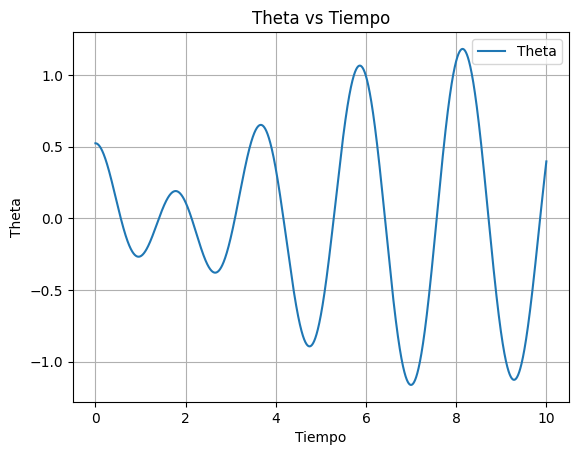

In [27]:
from metodos_ecuaciones_diferenciales import runge_kutta
import numpy as np
import matplotlib.pyplot as plt

def func(t, y):
    g =9.80665
    L =1
    Y = 0.25
    w = 2.5

    y1 =y[0]
    y2 =y[1]

    y1_prima = y2
    y2_prima = - (g / L) * np.sin(y1) + (w**2 / L) * Y * np.cos(y1) * np.sin(w * t)

    return np.array([y1_prima, y2_prima])

tiempos_runge_kutta, modelo_runge_kutta = runge_kutta(func, 0, 10, 0.001,[np.pi/6, 0])
modelo_runge_kutta = np.array(modelo_runge_kutta)
print(modelo_runge_kutta)
theta = (modelo_runge_kutta[:, 0])
theta_prima = (modelo_runge_kutta[:, 1])

plt.plot(tiempos_runge_kutta, theta, label='Theta')
plt.xlabel('Tiempo')
plt.ylabel('Theta')
plt.title('Theta vs Tiempo')
plt.legend()
plt.grid()
plt.show()




El valor máximo de $\theta$ es el siguiente

In [28]:
theta_max = max(theta)
print("El valor máximo de theta:", theta_max)

El valor máximo de theta: 1.1817750979571513


## 3.
 Dinámica de Burbuja-Litotricia: La litotricia es una técnica utilizada para destruir los cálculos que se forman en el riñón, la vejiga, los uréteres o la vesı́cula biliar. Hay varias formas de hacerla, aunque la más común es la litotricia extracorpórea (por fuera del cuerpo) por ondas de choque. Las ondas de choque se concentran en los cálculos y los rompen en fragmentos diminutos que luego salen del cuerpo en forma natural durante la micción. Los pulsos litotricios inducen cavitación, y las oscilaciones en los radios de las burbujas resultantes juegan un papel importante en la fragmentación de los cálculos. Howle, Schaeffer, Shearer, y Zhong (“Lithotripsy: The Treatment of Kidney Stone with Shock Waves”, SIAM Review, pp. 356-371, 1998) investigaron las vibraciones libres de esas cavitaciones que inducen burbujas de aire. El modelo que ellos consideran es una problema de valor inicial de segundo orden

$$
RR'' + \frac{3}{2}(R')^2 = a^2 [(\frac{R_o}{R})^{3 \gamma} - 1]
$$

$$R(0) = AR_o  ;  R'(0) = 0$$

donde los puntos denotan diferenciación con respecto al tiempo. R es la variación del radio de la burbuja de aire en el tempo, $R_o = 3 x 10^{-6}m$ es el radio de equilibrio de la burbuja, $\gamma = 1.4$ es el exponente adiabático, y $a = 10 \frac{m}{s}$

- a) Convierta el problema de valores iniciales en un sistema de ecuaciones diferenciales de primer orden.

- b) Solucione numéricamente el sistema de ecuaciones usando el método de Euler con $A = 2.5$ y $R_o = 1$

- c) Solucione numéricamente el sistema de ecuaciones usando el método de Rk4 con $A = 2.5$ y $R_o = 1$

- d) Grafique $R(t)$ vs $t$, $R'(t)$ vs $t$, $R(t)$ vs $R'(t)$

- e) ¿Cómo es la dinámica de la burbuja?, ¿Cómoǘaría el radio de la burbuja de aire con respecto al tiempo?, ¿cuál es el periodo (en segundos) de las oscialciones del radio?

## Item(a)

Primero vamos a redefinidir las siguientes variables:
- $y_1 = R$
- $y_2 = R'$

En donde :

- $y_1$: es el radio
- $y_2$: es la velocidad con la cambia el radio

Luego vamos a reemplazar estas variables en la ecuación original

$$
y_1 y_2' + \frac{3}{2}(y_2)^2 = a^2 [(\frac{R_o}{y_1})^{3 \gamma} - 1]
$$

Ahora despejamos a $y_2$:

$$
y_2' = \frac{a^2[(\frac{R_o}{y_1})^{3 \gamma} - 1] - \frac{3}{2}(y_2)^2}{y_1}
$$

Con todo lo anterior ya podemos armar un sistema ya que $y_1' = y_2$ 

## Item(b)

In [29]:
import numpy as np
from metodos_ecuaciones_diferenciales import metodo_euler_profe


def func(t, y ):
    """
    y1 = R
    y2 = R'
    """
    a = 10
    gamma = 1.5
    Ro = 1
    A = 2.5

    y1 = y[0]
    y2 = y[1]

    y1_prima = y2
    y2_prima = (a**2 * ((Ro/y1)**(3*gamma) - 1) - (3/2)*y2**2) / y1
    return np.array([y1_prima, y2_prima])


tiempos_euler, modelo_euler = metodo_euler_profe(func, 0, 0.1, 0.001, [2.5, 0])
print(modelo_euler)
R_euler = np.array(modelo_euler)[:,0]
R_prima_euler = np.array(modelo_euler)[:,1]


[[2.5, 0], array([ 2.5       , -0.03935237]), array([ 2.49996065, -0.07870566]), array([ 2.49988194, -0.11806232]), array([ 2.49976388, -0.15742477]), array([ 2.49960645, -0.19679544]), array([ 2.49940966, -0.23617679]), array([ 2.49917348, -0.27557123]), array([ 2.49889791, -0.31498123]), array([ 2.49858293, -0.35440922]), array([ 2.49822852, -0.39385765]), array([ 2.49783466, -0.43332899]), array([ 2.49740133, -0.4728257 ]), array([ 2.49692851, -0.51235025]), array([ 2.49641616, -0.55190512]), array([ 2.49586425, -0.5914928 ]), array([ 2.49527276, -0.63111579]), array([ 2.49464164, -0.6707766 ]), array([ 2.49397087, -0.71047774]), array([ 2.49326039, -0.75022174]), array([ 2.49251017, -0.79001116]), array([ 2.49172016, -0.82984854]), array([ 2.49089031, -0.86973646]), array([ 2.49002057, -0.90967751]), array([ 2.48911089, -0.94967428]), array([ 2.48816122, -0.98972939]), array([ 2.48717149, -1.02984548]), array([ 2.48614165, -1.0700252 ]), array([ 2.48507162, -1.11027124]), array([ 2

## Item(c)

In [30]:
import numpy as np
from metodos_ecuaciones_diferenciales import runge_kutta


def func(t, y ):
    """
    y1 = R
    y2 = R'
    """
    a = 10
    gamma = 1.5
    Ro = 1
    A = 2.5

    y1 = y[0]
    y2 = y[1]

    y1_prima = y2
    y2_prima = (a**2 * ((Ro/y1)**(3*gamma) - 1) - (3/2)*y2**2) / y1
    return np.array([y1_prima, y2_prima])


tiempos_runge_kutta, modelo_runge_kutta = runge_kutta(func, 0, 0.1, 0.001, [2.5, 0])
print(modelo_runge_kutta)
R_runge_kutta = np.array(modelo_runge_kutta)[:,0]
R_prima_runge_kutta = np.array(modelo_runge_kutta)[:,1]

[[2.5, 0], array([ 2.49998032, -0.03935277]), array([ 2.49992129, -0.07870797]), array([ 2.49982291, -0.11806804]), array([ 2.49968516, -0.15743541]), array([ 2.49950803, -0.19681251]), array([ 2.49929153, -0.23620179]), array([ 2.49903562, -0.27560568]), array([ 2.49874031, -0.31502664]), array([ 2.49840556, -0.35446712]), array([ 2.49803137, -0.39392957]), array([ 2.4976177 , -0.43341646]), array([ 2.49716453, -0.47293025]), array([ 2.49667183, -0.51247344]), array([ 2.49613957, -0.55204851]), array([ 2.49556772, -0.59165795]), array([ 2.49495624, -0.63130428]), array([ 2.4943051, -0.67099  ]), array([ 2.49361425, -0.71071766]), array([ 2.49288365, -0.7504898 ]), array([ 2.49211325, -0.79030897]), array([ 2.49130301, -0.83017774]), array([ 2.49045288, -0.87009869]), array([ 2.4895628 , -0.91007444]), array([ 2.48863271, -0.95010759]), array([ 2.48766256, -0.99020078]), array([ 2.48665229, -1.03035667]), array([ 2.48560183, -1.07057792]), array([ 2.48451111, -1.11086724]), array([ 2.4

## Item(d)

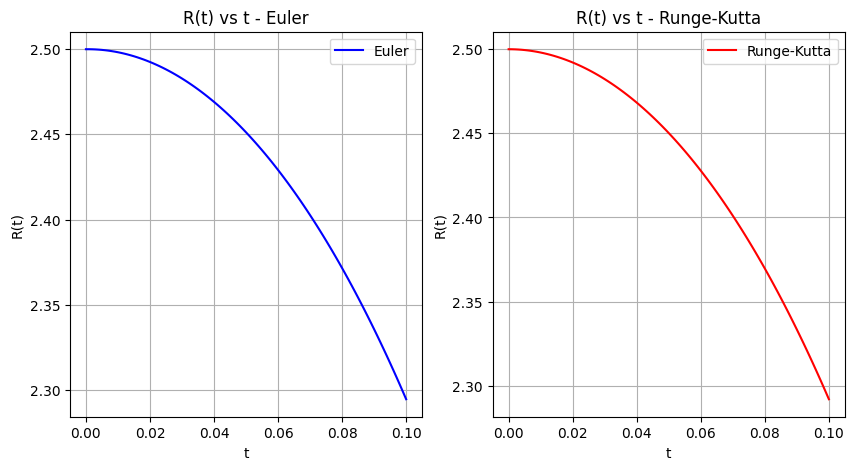

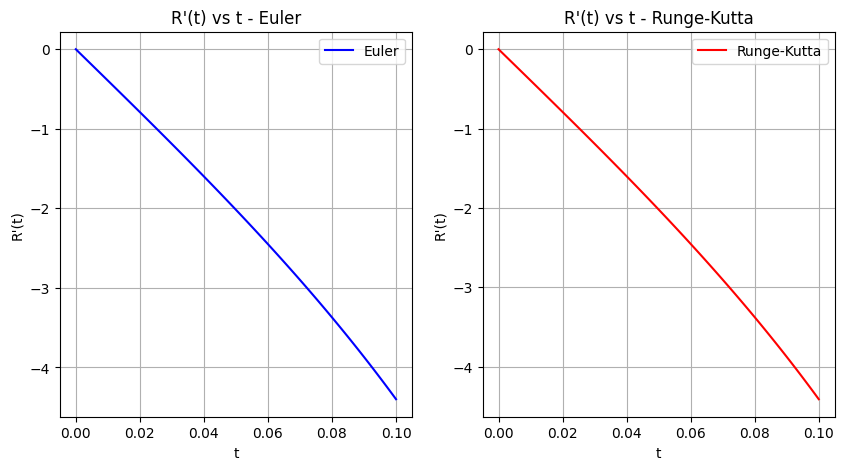

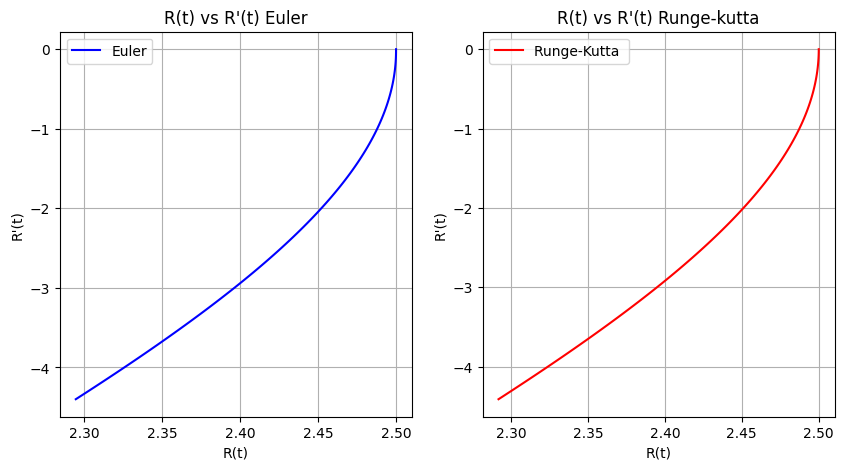

In [31]:
import matplotlib.pyplot as plt
# R vs t
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(tiempos_euler, R_euler, label="Euler", color='blue')
plt.title("R(t) vs t - Euler")
plt.xlabel("t")
plt.ylabel("R(t)")
plt.legend()
plt.grid()
plt.subplot(122)
plt.plot(tiempos_runge_kutta, R_runge_kutta, label="Runge-Kutta", color='red')
plt.title("R(t) vs t - Runge-Kutta")
plt.xlabel("t")
plt.ylabel("R(t)")
plt.legend()
plt.grid()
# R' vs t
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(tiempos_euler, R_prima_euler, label="Euler", color='blue')
plt.title("R'(t) vs t - Euler")
plt.xlabel("t")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()
plt.subplot(122)
plt.plot(tiempos_runge_kutta, R_prima_runge_kutta, label="Runge-Kutta", color='red')
plt.title("R'(t) vs t - Runge-Kutta")
plt.xlabel("t")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()

# R vs R'
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(R_euler, R_prima_euler, label="Euler", color='blue')
plt.title("R(t) vs R'(t) Euler")
plt.xlabel("R(t)")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()
plt.subplot(122)
plt.plot(R_runge_kutta, R_prima_runge_kutta, label="Runge-Kutta ", color='red')
plt.title("R(t) vs R'(t) Runge-kutta")
plt.xlabel("R(t)")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()


## Item(e)

In [32]:
# TODO

## Conclusiones

- La burbuja oscila alrededor de su radio de equilibrio ($R_o$)
- La amplitud de oscilación decrece con el tiempo (disipación de energía)
- El período depende de los parámetros físicos ($a$, $\gamma$, $R_o$)
- El diagrama de fase muestra una espiral que converge al punto de equilibrio

## 4.

Un biólogo midió la longitud de un esturión por un periodo de 21 años. La tabla muestra el conjunto de datos resultantes donde la longitud $L$ se encuentra en cm y el tiempo en años.

- a) Usé interpolación polinomial simple para determinar la longitud de un esturión en un tiempo de 20.5 años.
- b) Use aproximación a un solo término y construya un modelo no lineal para predecir la longitud de un esturión en un tiempo de 20.5 años.

![tabla](https://i.gyazo.com/5a6f2fe51b56119e730d175a942f682a.png)

In [33]:
import numpy as np
from interpolacion import lagrange_pol

def Matrix(Px):
    """
    Genera la matriz de coeficientes para dar solución.
    ----------
    Parametros:
    -----------
    Px : array
        Vector de puntos x
    Retorna:
    --------
    A : array
        Matriz de coeficientes
    ----------
    """
    n = len(Px)

    A = np.zeros([n, n])
    for i in range(n):
        A[i, 0] = 1
        for j in range(1, n):
            A[i, j] = A[i, j-1] * Px[i]
    return A

def polynom_generator(coef, n):
    """
    Generador de polinomio de grado N.
    ----------
    Parametros:
    -----------
    n : int
        Grado del polinomio
    Retorna:
    --------
    pol_n : function
        Funcion que evalua el polinomio de grado N
    """
    pol_n = lambda x: sum([coef[i] * x**i for i in range(n)])
    return pol_n


anios = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21])
longitud = np.array([21.1, 32.0, 42.3, 51.4, 60.1, 68.0, 75.3, 75.3, 89.0, 95.3, 101.6, 107.6, 127.7, 117.7, 122.2, 126.5, 130.9, 135.3, 135.3, 145.0, 148.6, 152.0])

polinomio_lagrange = lagrange_pol(anios, longitud)
print("Polinomio de Lagrange:")
print(polinomio_lagrange)



Polinomio de Lagrange:
-1.01080656971318e-13*x**21 + 2.22179221022186e-11*x**20 - 2.28112331981097e-9*x**19 + 1.45333722849156e-7*x**18 - 6.43815396595362e-6*x**17 + 0.000210578384790928*x**16 - 0.0052706638685936*x**15 + 0.103246918024874*x**14 - 1.60539941668307*x**13 + 19.9790028516224*x**12 - 199.737408868279*x**11 + 1603.74849418498*x**10 - 10300.2627323344*x**9 + 52488.8273830127*x**8 - 209487.902244516*x**7 + 642308.809240645*x**6 - 1470626.77344486*x**5 + 2409173.32325362*x**4 - 2636480.61949501*x**3 + 1701007.70916804*x**2 - 479494.693997889*x + 21.1


In [34]:
import sympy as sp
x = sp.symbols('x')
polinomio_lagrange = sp.lambdify(x, polinomio_lagrange)
polinomio_lagrange_20_5 = polinomio_lagrange(20.5)
print(f"Predicción para t = 20.5: {polinomio_lagrange_20_5} cm")

Predicción para t = 20.5: 36820.11737320423 cm


Graficando los datos observados y asimismo viendo si la predicicón es precisa

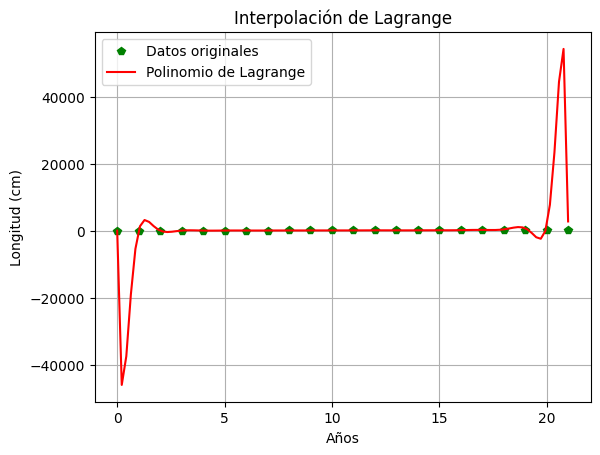

In [35]:
import matplotlib.pyplot as plt

ux = np.linspace(min(anios), max(anios), 100)

plt.plot(anios, longitud, 'gp', label='Datos originales')
plt.plot(ux, polinomio_lagrange(ux), 'r', label='Polinomio de Lagrange')
plt.xlabel('Años')
plt.ylabel('Longitud (cm)')
plt.title('Interpolación de Lagrange')
plt.grid()
plt.legend()

## Item(b)

<module 'matplotlib.pyplot' from '/home/felipe/Desktop/5to/Analisis_numerico/venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

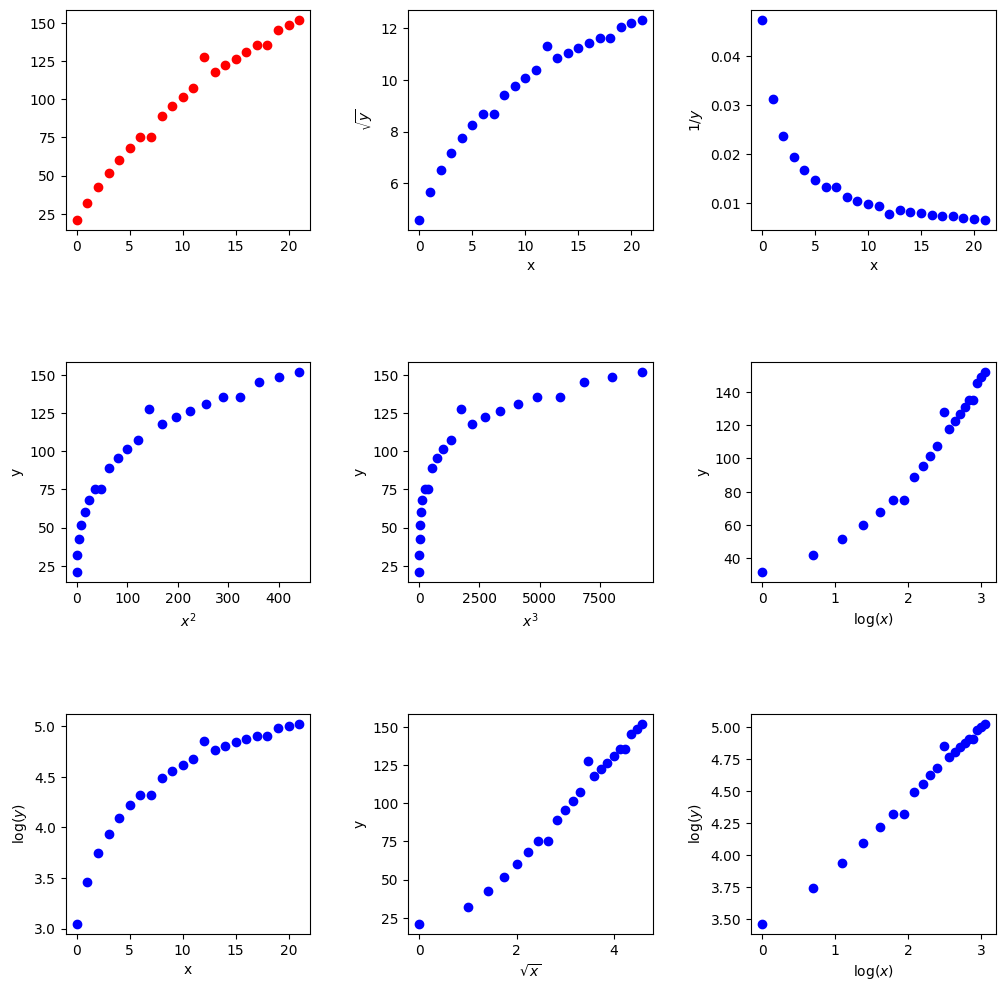

In [36]:
from graficar_escalas import graficar_escalas

graficar_escalas(anios, longitud)

De acuerdo a lo anterior podemos darnos cuenta que el modelo que más se ajusta es $log(y) log(x)$

a0: 3.6563009295099578, a1: 0.4183023317564882


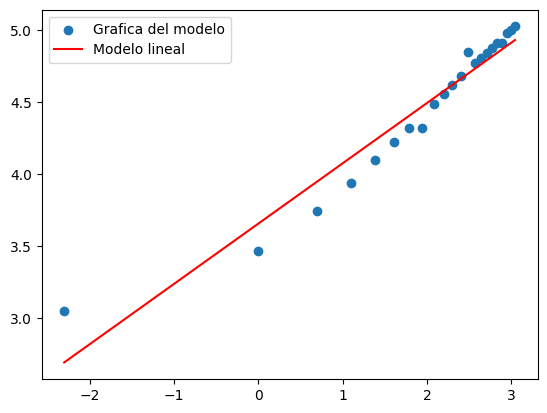

In [47]:
from minimos_cuadrados_funcion import minimos_cuadrados

x_data = np.array([0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21])
y_data = np.array([21.1, 32.0, 42.3, 51.4, 60.1, 68.0, 75.3, 75.3, 89.0, 95.3, 101.6, 107.6, 127.7, 117.7, 122.2, 126.5, 130.9, 135.3, 135.3, 145.0, 148.6, 152.0])

a0, a1 = minimos_cuadrados(np.log(x_data), np.log(y_data))

print(f"a0: {a0}, a1: {a1}")
ux = np.linspace(min(np.log(x_data)), max(np.log(x_data)))
P = lambda x: a0 + a1 * x
plt.scatter(np.log(x_data), np.log(y_data), label='Grafica del modelo')
plt.plot(ux, P(ux),'r', label='Modelo lineal')
plt.legend()

En la gráfica anterior se observa que el modelo si se ajusta, ahora vamos a graficar el modelo con los datos observados

### Graficando el modelo no lineal

### Partir de $Y=a_0+a_1x$, dependiendo de la escala en este caso $log(x), log(y)$ es el modelo no lineal es:

$$log(y) = a_0+a_1log(x)$$
$$y = e^{a_0 + log(x^{a_1})}$$
$$M = e^{a_0}*x^{a_1}$$

Con el polinomio M ya se pueden hacer predicciones para el caso específico

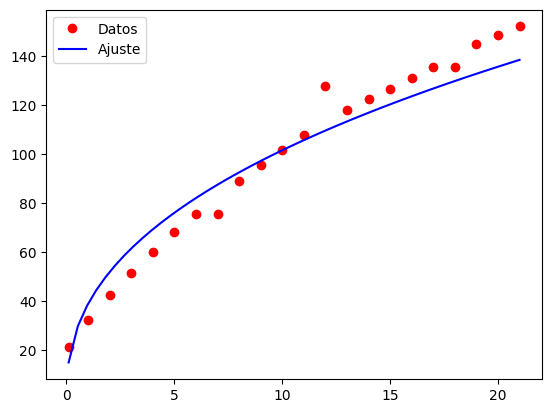

In [48]:
u_x = np.linspace(min(x_data), max(x_data))
M = lambda x: np.exp(a0) * x**a1

plt.plot(x_data,y_data, 'or', label="Datos")
plt.plot(u_x, M(u_x), 'b', label="Ajuste")
plt.legend()

De lo anterior ya podemos predecir más certeramente y resolver el item a continuación:

In [49]:
# Prediccion del estrion t =20.5
prediccion = M(20.5)
print(f"Predicción para t = 20.5: {prediccion} cm")

Predicción para t = 20.5: 136.96859997278457 cm


Se puede ver que es un valor mucho más acertado y acorde con los valores vecinos que presenta la tabla con los datos, así que podemos asegurar que es correcto.